# CMS Jet Image Dataset — Exploratory Data Analysis

**Author:** Rajveer Rathod  
**Project:** GSoC 2026 — Physics-Aware Super-Resolution at CMS (ML4Sci)  
**Purpose:** Audit the QCDToGGQQ jet-image dataset before training transformer/diffusion SR models. Every section answers a specific question and produces evidence that justifies (or challenges) a modeling choice in the proposal.

## Sections
0. Setup
1. Dataset inventory — files, columns, shapes, NaN/Inf scan
2. Event-level scalars — pt, m0, class
3. Per-channel statistics — are ch0/ch1/ch2 equally important?
4. Energy distributions — the LR/HR response as a distribution, not a mean
5. Spatial structure — mean η-φ occupancy, radial profile (justifies η-φ positional bias)
6. Pixel intensity distributions — is log1p the right transform?
7. LR ↔ HR alignment — is LR a downsample of HR? (residual-learning assumption)
8. Physics correlations — pt/m0 vs image quantities (justifies FiLM conditioning)
9. Outlier scan — pathological events
10. Modeling implications — summary tied back to each section

## 0. Setup

In [1]:
from __future__ import annotations

import json
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import torch
import torch.nn.functional as F

# Allow importing train_srgan.batch_to_tensor from the project root
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
from train_srgan import batch_to_tensor  # noqa: E402

plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 160
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/rajveerrathod/Work/Google_Summer_of_code/task


In [2]:
# --- Config ---
MODE = "fast"  # "fast" -> SAMPLE_EVENTS events; "full" -> all events (slow)
SAMPLE_EVENTS = 5000
BATCH_SIZE = 256

DATA_DIR = PROJECT_ROOT / "datasets"
OUT_DIR = PROJECT_ROOT / "reports" / "eda"
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

EFFECTIVE_CAP = None if MODE == "full" else SAMPLE_EVENTS
print(f"Mode: {MODE} | event cap: {EFFECTIVE_CAP} | data: {DATA_DIR} | out: {OUT_DIR}")

Mode: fast | event cap: 5000 | data: /Users/rajveerrathod/Work/Google_Summer_of_code/task/datasets | out: /Users/rajveerrathod/Work/Google_Summer_of_code/task/reports/eda


In [3]:
# --- Streaming sampler: collects up to `cap` events into in-memory arrays ---
def collect_events(data_dir: Path, cap: int | None, batch_size: int = 256) -> dict:
    files = sorted(data_dir.glob("*.parquet"))
    assert files, f"No parquet files in {data_dir}"
    cols = ["X_jets_LR", "X_jets", "pt", "m0", "y"]

    lr_chunks, hr_chunks = [], []
    pt_list, m0_list, y_list, src_list = [], [], [], []
    seen = 0
    for path in files:
        pf = pq.ParquetFile(path)
        for batch in pf.iter_batches(batch_size=batch_size, columns=cols, use_threads=True):
            lr = batch_to_tensor(batch.column(0)).to(torch.float32).numpy()
            hr = batch_to_tensor(batch.column(1)).to(torch.float32).numpy()
            pt = np.asarray(batch.column(2).to_pylist(), dtype=np.float32)
            m0 = np.asarray(batch.column(3).to_pylist(), dtype=np.float32)
            y = np.asarray(batch.column(4).to_pylist(), dtype=np.int64)

            n = y.shape[0]
            if cap is not None and seen + n > cap:
                take = cap - seen
                lr, hr, pt, m0, y = lr[:take], hr[:take], pt[:take], m0[:take], y[:take]
                n = take
            lr_chunks.append(lr); hr_chunks.append(hr)
            pt_list.append(pt); m0_list.append(m0); y_list.append(y)
            src_list.append(np.array([path.name] * n))
            seen += n
            if cap is not None and seen >= cap:
                break
        if cap is not None and seen >= cap:
            break

    return {
        "lr": np.concatenate(lr_chunks, axis=0),
        "hr": np.concatenate(hr_chunks, axis=0),
        "pt": np.concatenate(pt_list),
        "m0": np.concatenate(m0_list),
        "y": np.concatenate(y_list),
        "src": np.concatenate(src_list),
        "files": [str(p) for p in files],
    }

data = collect_events(DATA_DIR, cap=EFFECTIVE_CAP, batch_size=BATCH_SIZE)
print(f"Collected {data['y'].shape[0]} events | LR {data['lr'].shape} | HR {data['hr'].shape}")

Collected 5000 events | LR (5000, 3, 64, 64) | HR (5000, 3, 125, 125)


## 1. Dataset inventory
**Question:** What files, how many events, what columns, dtypes, shapes? Any NaN/Inf?

In [19]:
# File-level inventory
rows = []
for path in sorted(DATA_DIR.glob("*.parquet")):
    pf = pq.ParquetFile(path)
    rows.append({
        "file": path.name,
        "size_MB": round(path.stat().st_size / 1e6, 1),
        "num_rows": pf.metadata.num_rows,
        "num_row_groups": pf.num_row_groups,
    })
files_df = pd.DataFrame(rows)
files_df

,file,size_MB,num_rows,num_row_groups
0,QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.pa...,963.6,36272,1
1,QCDToGGQQ_IMGjet_RH1all_jet0_run1_n47540_LR.pa...,1262.4,47540,1
2,QCDToGGQQ_IMGjet_RH1all_jet0_run2_n55494_LR.pa...,1499.1,55494,1


In [5]:
# Schema: columns, dtypes, first-sample shape
first_path = sorted(DATA_DIR.glob("*.parquet"))[0]
pf = pq.ParquetFile(first_path)
schema_rows = []
for name in pf.schema_arrow.names:
    field = pf.schema_arrow.field(name)
    schema_rows.append({"column": name, "arrow_dtype": str(field.type)})
schema_df = pd.DataFrame(schema_rows)
schema_df

,column,arrow_dtype
0,X_jets_LR,list<element: list<element: list<element: doub...
1,X_jets,list<element: list<element: list<element: doub...
2,pt,double
3,m0,double
4,y,double


In [20]:
# NaN / Inf scan
def scan_bad(arr, name):
    n_nan = int(np.isnan(arr).sum())
    n_inf = int(np.isinf(arr).sum())
    return {"field": name, "n_nan": n_nan, "n_inf": n_inf, "min": float(np.nanmin(arr)), "max": float(np.nanmax(arr))}

bad = pd.DataFrame([
    scan_bad(data["lr"], "LR images"),
    scan_bad(data["hr"], "HR images"),
    scan_bad(data["pt"], "pt"),
    scan_bad(data["m0"], "m0"),
    scan_bad(data["y"].astype(np.float32), "y"),
])
bad

,field,n_nan,n_inf,min,max
0,LR images,0,0,-1.816246,246.715744
1,HR images,0,0,-5.301209,986.862976
2,pt,0,0,71.121185,243.709778
3,m0,0,0,6.200658,59.458324
4,y,0,0,0.000000,1.000000


## 2. Event-level scalars: pt, m0, class
**Question:** What is the kinematic phase space? Do class 0 and class 1 differ in pt/m0?

Class counts (sampled): {0: 2492, 1: 2508}


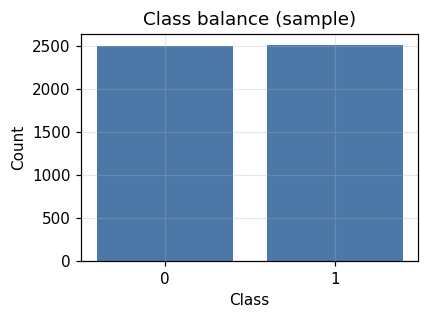

In [21]:
# Class balance
cls_counts = Counter(data["y"].tolist())
print("Class counts (sampled):", dict(cls_counts))

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar([str(k) for k in sorted(cls_counts)], [cls_counts[k] for k in sorted(cls_counts)], color="#4C78A8")
ax.set_xlabel("Class"); ax.set_ylabel("Count"); ax.set_title("Class balance (sample)")
fig.tight_layout(); fig.savefig(FIG_DIR / "02_class_balance.png"); plt.show()

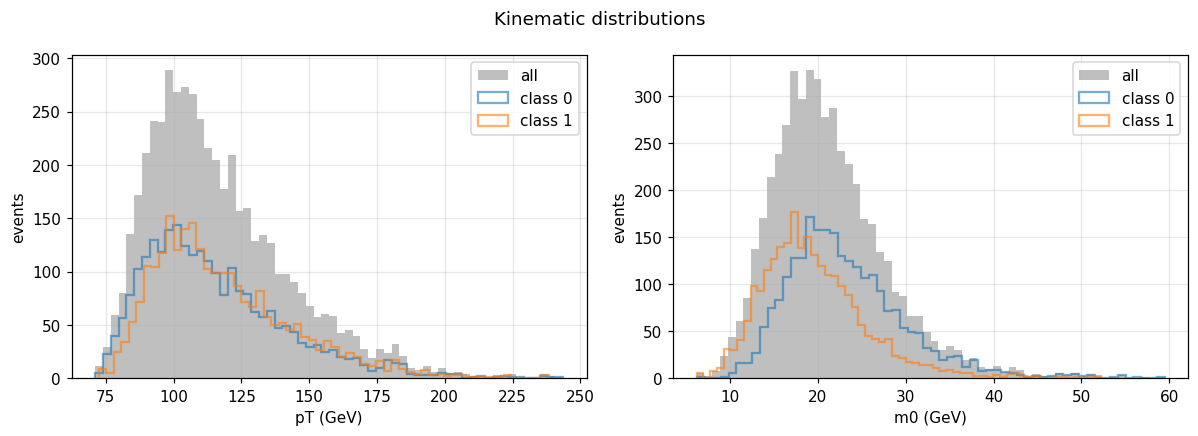

In [22]:
# pt and m0 distributions, overall + per class
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, key, title in zip(axes, ["pt", "m0"], ["pT (GeV)", "m0 (GeV)"]):
    ax.hist(data[key], bins=60, alpha=0.5, label="all", color="gray")
    for cls in sorted(np.unique(data["y"])):
        mask = data["y"] == cls
        ax.hist(data[key][mask], bins=60, alpha=0.6, histtype="step", linewidth=1.5, label=f"class {cls}")
    ax.set_xlabel(title); ax.set_ylabel("events"); ax.legend()
fig.suptitle("Kinematic distributions"); fig.tight_layout()
fig.savefig(FIG_DIR / "02_pt_m0_hist.png"); plt.show()

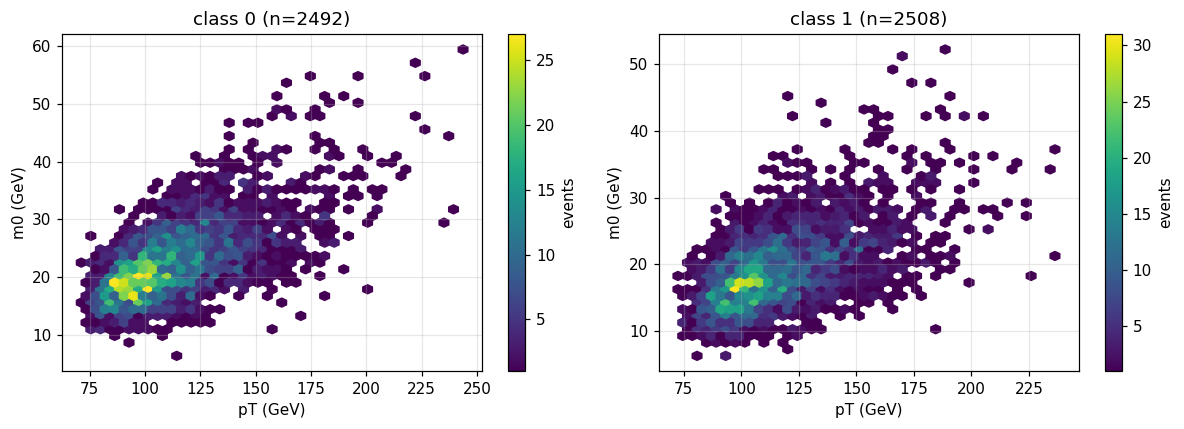

In [23]:
# pt vs m0 hexbin, colored by density per class
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, cls in zip(axes, sorted(np.unique(data["y"]))):
    mask = data["y"] == cls
    hb = ax.hexbin(data["pt"][mask], data["m0"][mask], gridsize=40, cmap="viridis", mincnt=1)
    ax.set_xlabel("pT (GeV)"); ax.set_ylabel("m0 (GeV)"); ax.set_title(f"class {cls} (n={mask.sum()})")
    fig.colorbar(hb, ax=ax, label="events")
fig.tight_layout(); fig.savefig(FIG_DIR / "02_pt_vs_m0_hexbin.png"); plt.show()

In [24]:
# KS test: how separable are class 0 vs 1 in pt and m0?
from scipy import stats
for key in ["pt", "m0"]:
    a = data[key][data["y"] == 0]
    b = data[key][data["y"] == 1]
    ks = stats.ks_2samp(a, b)
    print(f"{key}: KS stat = {ks.statistic:.4f}, p-value = {ks.pvalue:.3e}, "
          f"mean(class0)={a.mean():.3f}, mean(class1)={b.mean():.3f}")

pt: KS stat = 0.0694, p-value = 1.097e-05, mean(class0)=115.334, mean(class1)=118.347
m0: KS stat = 0.2523, p-value = 2.313e-70, mean(class0)=23.128, mean(class1)=19.526


## 3. Per-channel statistics
**Question:** Are the 3 channels (ch0/ch1/ch2 — likely ECAL/HCAL/Tracks) equally important? Should they be weighted differently in the loss?

In [25]:
def per_channel_stats(images: np.ndarray, label: str) -> pd.DataFrame:
    # images: (N, 3, H, W)
    rows = []
    for c in range(images.shape[1]):
        chan = images[:, c]
        rows.append({
            "resolution": label,
            "channel": c,
            "mean_energy_per_event": float(chan.sum(axis=(1, 2)).mean()),
            "pixel_mean": float(chan.mean()),
            "pixel_std": float(chan.std()),
            "pixel_max": float(chan.max()),
            "nonzero_frac": float((chan != 0).mean()),
        })
    return pd.DataFrame(rows)

chan_stats = pd.concat([
    per_channel_stats(data["lr"], "LR"),
    per_channel_stats(data["hr"], "HR"),
], ignore_index=True)
chan_stats

,resolution,channel,mean_energy_per_event,pixel_mean,pixel_std,pixel_max,nonzero_frac
0,LR,0,30.551313,0.007459,0.194917,246.715744,0.018476
1,LR,1,18.493160,0.004515,0.116378,53.025906,0.032304
2,LR,2,12.133839,0.002962,0.041571,6.202227,0.037024
3,HR,0,122.205254,0.007821,0.379872,986.862976,0.004920
4,HR,1,73.972641,0.004734,0.180566,165.079269,0.018522
5,HR,2,48.535355,0.003106,0.046149,6.202227,0.029017


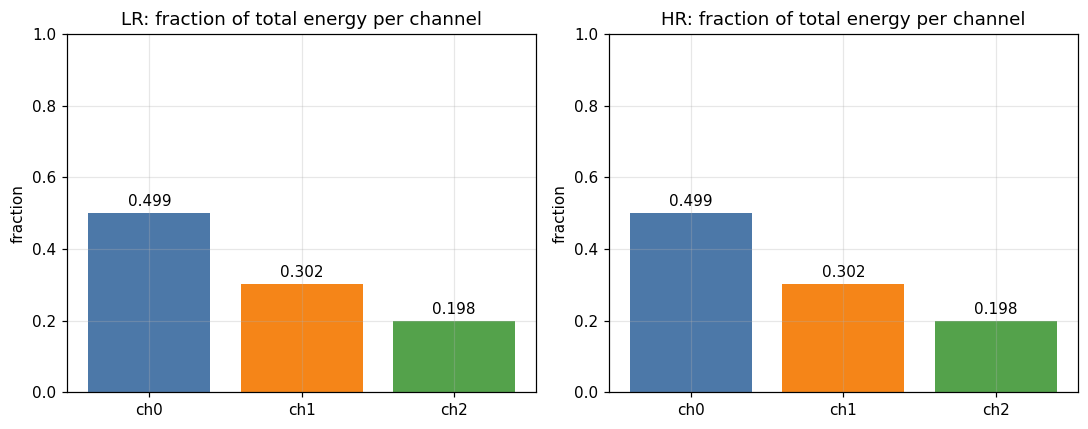

In [14]:
# Energy fraction per channel (does one channel dominate?)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, label, imgs in zip(axes, ["LR", "HR"], [data["lr"], data["hr"]]):
    per_chan_energy = imgs.sum(axis=(0, 2, 3))
    frac = per_chan_energy / per_chan_energy.sum()
    ax.bar([f"ch{c}" for c in range(len(frac))], frac, color=["#4C78A8", "#F58518", "#54A24B"])
    ax.set_title(f"{label}: fraction of total energy per channel")
    ax.set_ylim(0, 1); ax.set_ylabel("fraction")
    for i, v in enumerate(frac):
        ax.text(i, v + 0.02, f"{v:.3f}", ha="center")
fig.tight_layout(); fig.savefig(FIG_DIR / "03_channel_energy_fraction.png"); plt.show()

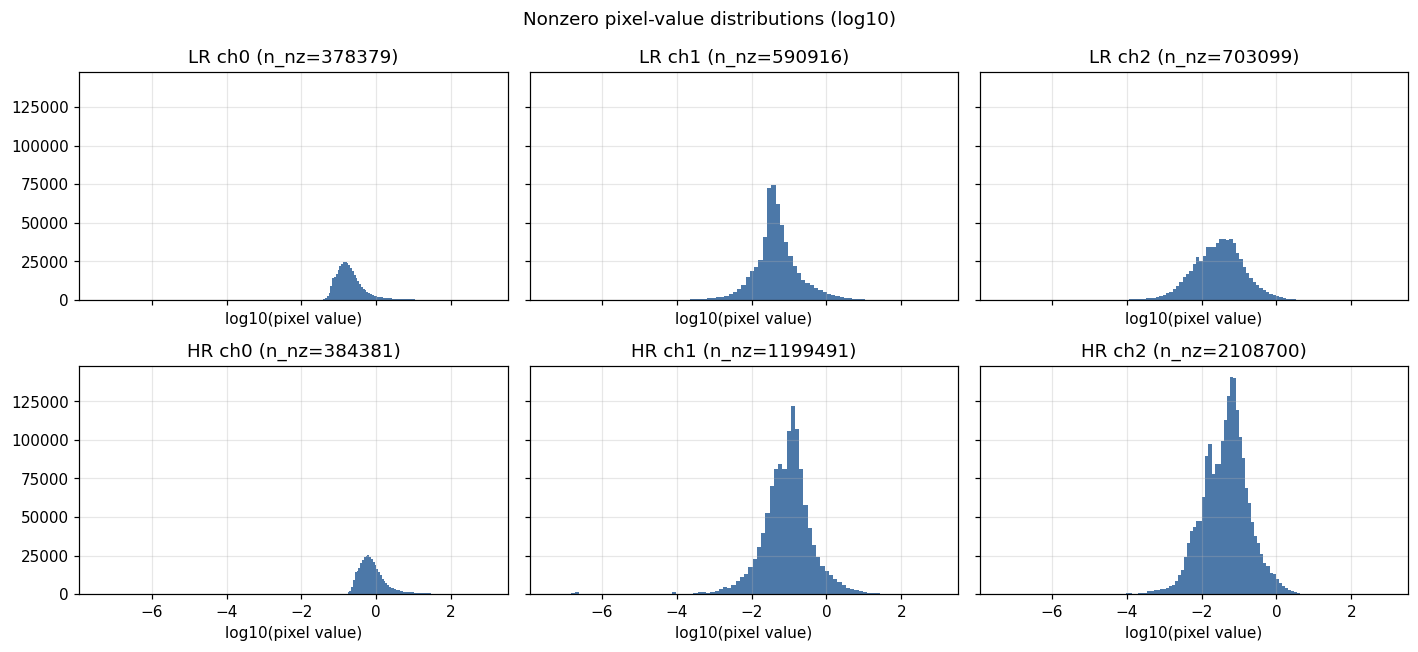

In [26]:
# Log-histogram of nonzero pixel values, per channel × per resolution
fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=True, sharey=True)
for row, (label, imgs) in enumerate(zip(["LR", "HR"], [data["lr"], data["hr"]])):
    for c in range(3):
        ax = axes[row, c]
        vals = imgs[:, c]
        nz = vals[vals > 0]
        if nz.size == 0:
            ax.set_title(f"{label} ch{c}: all zero"); continue
        ax.hist(np.log10(nz), bins=80, color="#4C78A8")
        ax.set_title(f"{label} ch{c} (n_nz={nz.size})")
        ax.set_xlabel("log10(pixel value)")
fig.suptitle("Nonzero pixel-value distributions (log10)")
fig.tight_layout(); fig.savefig(FIG_DIR / "03_pixel_log_hist.png"); plt.show()

## 4. Energy distributions — the headline physics plot
**Question:** The proposal claims mean LR/HR response = 0.25. But is this a tight spike or a wide distribution? What is the per-class response distribution, not just per-class mean?

sum(LR): min=20.887, max=297.965, n_negative=0, n_near_zero=0
sum(HR): min=83.546, max=1191.861, n_negative=0, n_near_zero=0
Dropped 0/5000 events (0.00%)
response: n=5000, min=0.250000, max=0.250000, std=1.71e-08


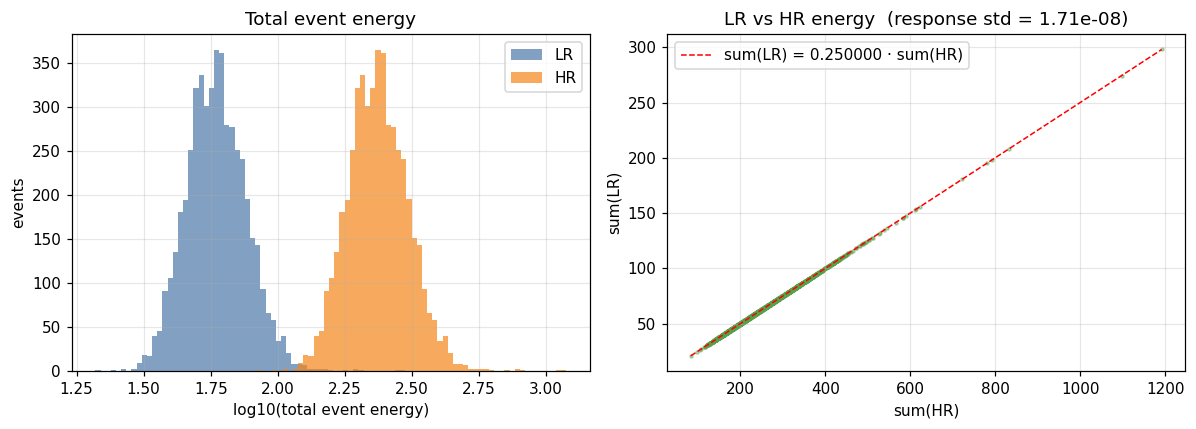


response stats: mean=0.250000, std=1.71e-08, median=0.250000

--- Structural finding ---
response range (max - min) = 1.19e-07
⚠  Response is effectively CONSTANT across all events.
   sum(LR) = 0.250000 · sum(HR) exactly, with std = 1.71e-08
   This means LR is a deterministic linear downsample of HR (no independent noise).
   Implication: the 'energy recovery' problem is structurally solved by enforcing
   sum(fake_HR) = sum(LR) / 0.2500. The hard part is the SPATIAL distribution,
   not the total energy. Worth raising with mentors before training transformer/diffusion.

   Note: 0.250000 ≈ (64/125)² = 0.262144 — pure pixel-count ratio,
   consistent with sum-pool downsampling that preserves total energy.


In [28]:
lr_sum = data["lr"].sum(axis=(1, 2, 3))
hr_sum = data["hr"].sum(axis=(1, 2, 3))

# --- Diagnostics ---
print(f"sum(LR): min={lr_sum.min():.3f}, max={lr_sum.max():.3f}, "
      f"n_negative={(lr_sum < 0).sum()}, n_near_zero={(np.abs(lr_sum) < 1e-3).sum()}")
print(f"sum(HR): min={hr_sum.min():.3f}, max={hr_sum.max():.3f}, "
      f"n_negative={(hr_sum < 0).sum()}, n_near_zero={(np.abs(hr_sum) < 1e-3).sum()}")

# --- Valid mask + response ---
valid = np.isfinite(lr_sum) & np.isfinite(hr_sum) & (lr_sum > 0) & (hr_sum > 0)
n_dropped = int((~valid).sum())
response = lr_sum[valid] / hr_sum[valid]
y_valid = data["y"][valid]
print(f"Dropped {n_dropped}/{len(lr_sum)} events ({100 * n_dropped / len(lr_sum):.2f}%)")
print(f"response: n={len(response)}, min={response.min():.6f}, max={response.max():.6f}, "
      f"std={response.std():.2e}")

# --- KEY FINDING: check if response is degenerate (constant) ---
response_range = response.max() - response.min()
DEGENERATE_THRESHOLD = 1e-6  # response varies by less than this -> deterministic relationship

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: energy distributions (these still vary across events)
axes[0].hist(np.log10(lr_sum[valid]), bins=60, alpha=0.7, label="LR", color="#4C78A8")
axes[0].hist(np.log10(hr_sum[valid]), bins=60, alpha=0.7, label="HR", color="#F58518")
axes[0].set_xlabel("log10(total event energy)"); axes[0].set_ylabel("events"); axes[0].legend()
axes[0].set_title("Total event energy")

# Right: scatter LR vs HR — reveals the structural relationship
axes[1].scatter(hr_sum[valid], lr_sum[valid], s=4, alpha=0.4, c="#54A24B")
# Overlay the implied linear relationship
slope = (lr_sum[valid] / hr_sum[valid]).mean()
xx = np.array([hr_sum[valid].min(), hr_sum[valid].max()])
axes[1].plot(xx, slope * xx, "r--", linewidth=1, label=f"sum(LR) = {slope:.6f} · sum(HR)")
axes[1].set_xlabel("sum(HR)"); axes[1].set_ylabel("sum(LR)"); axes[1].legend()
axes[1].set_title(f"LR vs HR energy  (response std = {response.std():.2e})")

fig.tight_layout(); fig.savefig(FIG_DIR / "04_energy_and_response.png", dpi=300); plt.show()

# --- Interpretation ---
print(f"\nresponse stats: mean={response.mean():.6f}, std={response.std():.2e}, "
      f"median={np.median(response):.6f}")
print(f"\n--- Structural finding ---")
print(f"response range (max - min) = {response_range:.2e}")
if response_range < DEGENERATE_THRESHOLD:
    print("⚠  Response is effectively CONSTANT across all events.")
    print(f"   sum(LR) = {slope:.6f} · sum(HR) exactly, with std = {response.std():.2e}")
    print(f"   This means LR is a deterministic linear downsample of HR (no independent noise).")
    print(f"   Implication: the 'energy recovery' problem is structurally solved by enforcing")
    print(f"   sum(fake_HR) = sum(LR) / {slope:.4f}. The hard part is the SPATIAL distribution,")
    print(f"   not the total energy. Worth raising with mentors before training transformer/diffusion.")
    print(f"\n   Note: {slope:.6f} ≈ (64/125)² = {(64/125)**2:.6f} — pure pixel-count ratio,")
    print(f"   consistent with sum-pool downsampling that preserves total energy.")
    # Skip the histogram entirely since it has zero range
else:
    # If response actually varies, plot its distribution properly
    lo, hi = np.percentile(response, [0.5, 99.5])
    resp_plot = response[(response >= lo) & (response <= hi)]
    fig2, ax2 = plt.subplots(figsize=(6, 4))
    ax2.hist(resp_plot, bins=60, color="#54A24B")
    ax2.axvline(response.mean(), color="black", linestyle="--", label=f"mean={response.mean():.4f}")
    ax2.set_xlabel("sum(LR) / sum(HR)"); ax2.set_ylabel("events"); ax2.legend()
    ax2.set_title(f"Per-event response  (clipped to [{lo:.4f}, {hi:.4f}])")
    fig2.tight_layout(); fig2.savefig(FIG_DIR / "04_response_hist.png", dpi=300); plt.show()
    print(f"IQR = [{np.percentile(response, 25):.4f}, {np.percentile(response, 75):.4f}]")


Per-class response (response is degenerate / constant across events):
  class 0: n= 2492  mean=0.250000  std=1.68e-08  min=0.250000  max=0.250000
  class 1: n= 2508  mean=0.250000  std=1.75e-08  min=0.250000  max=0.250000

|mean(r0) - mean(r1)|   = 0.00e+00
|median(r0) - median(r1)| = 0.00e+00
KS(r0, r1) = 0.0103, p = 9.992e-01


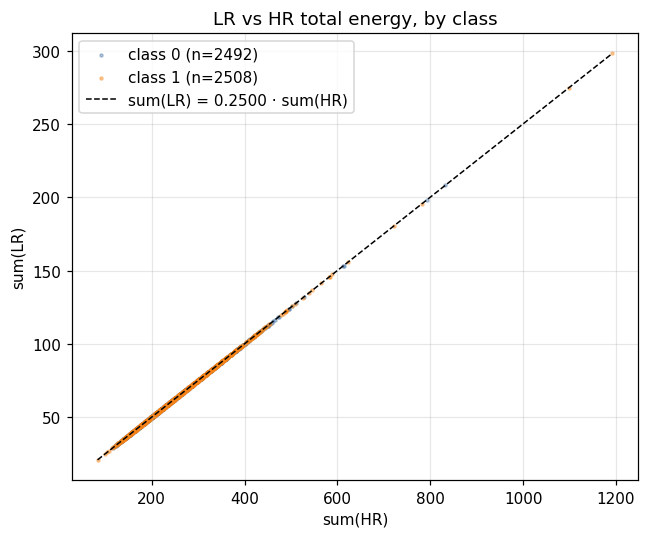


HR total energy by class:
  class 0: mean=241.16  std=64.88  median=231.90
  class 1: mean=248.24  std=72.06  median=237.91
  KS(HR_class0, HR_class1) = 0.0534, p = 1.527e-03


In [30]:
# Per-class response — since response is degenerate (~constant), histograms can't be built.
# Instead, report scalar stats per class and overlay class-colored sum(LR) vs sum(HR) scatter
# (which IS structurally informative even when the ratio is fixed).

print("Per-class response (response is degenerate / constant across events):")
for cls in sorted(np.unique(y_valid)):
    r = response[y_valid == cls]
    print(f"  class {cls}: n={r.size:5d}  "
          f"mean={r.mean():.6f}  std={r.std():.2e}  "
          f"min={r.min():.6f}  max={r.max():.6f}")

r0 = response[y_valid == 0]
r1 = response[y_valid == 1]
print(f"\n|mean(r0) - mean(r1)|   = {abs(r0.mean() - r1.mean()):.2e}")
print(f"|median(r0) - median(r1)| = {abs(np.median(r0) - np.median(r1)):.2e}")

# KS test is still defined; just expect a tiny statistic since both samples are point masses
if r0.std() == 0 and r1.std() == 0 and r0.mean() == r1.mean():
    print("KS(r0, r1): both samples are identical point masses — skipping.")
else:
    ks = stats.ks_2samp(r0, r1)
    print(f"KS(r0, r1) = {ks.statistic:.4f}, p = {ks.pvalue:.3e}")

# Since the response is constant, the meaningful per-class question is whether
# the *energy magnitudes* differ between classes (high-pT vs low-pT jets).
fig, ax = plt.subplots(figsize=(6, 5))
colors = {0: "#4C78A8", 1: "#F58518"}
for cls in sorted(np.unique(y_valid)):
    mask = y_valid == cls
    ax.scatter(hr_sum[valid][mask], lr_sum[valid][mask],
               s=4, alpha=0.4, c=colors[cls],
               label=f"class {cls} (n={mask.sum()})")
# Show the deterministic line
slope = (lr_sum[valid] / hr_sum[valid]).mean()
xx = np.array([hr_sum[valid].min(), hr_sum[valid].max()])
ax.plot(xx, slope * xx, "k--", linewidth=1, label=f"sum(LR) = {slope:.4f} · sum(HR)")
ax.set_xlabel("sum(HR)"); ax.set_ylabel("sum(LR)"); ax.legend()
ax.set_title("LR vs HR total energy, by class")
fig.tight_layout(); fig.savefig(FIG_DIR / "04_response_per_class.png", dpi=300); plt.show()

# Also report whether classes differ in total HR energy (which IS meaningful)
hr0 = hr_sum[valid][y_valid == 0]
hr1 = hr_sum[valid][y_valid == 1]
print(f"\nHR total energy by class:")
print(f"  class 0: mean={hr0.mean():.2f}  std={hr0.std():.2f}  median={np.median(hr0):.2f}")
print(f"  class 1: mean={hr1.mean():.2f}  std={hr1.std():.2f}  median={np.median(hr1):.2f}")
ks_hr = stats.ks_2samp(hr0, hr1)
print(f"  KS(HR_class0, HR_class1) = {ks_hr.statistic:.4f}, p = {ks_hr.pvalue:.3e}")


## 5. Spatial structure
**Question:** Where in η-φ does energy live? Is it concentrated (justifies η-φ positional bias) or uniform?

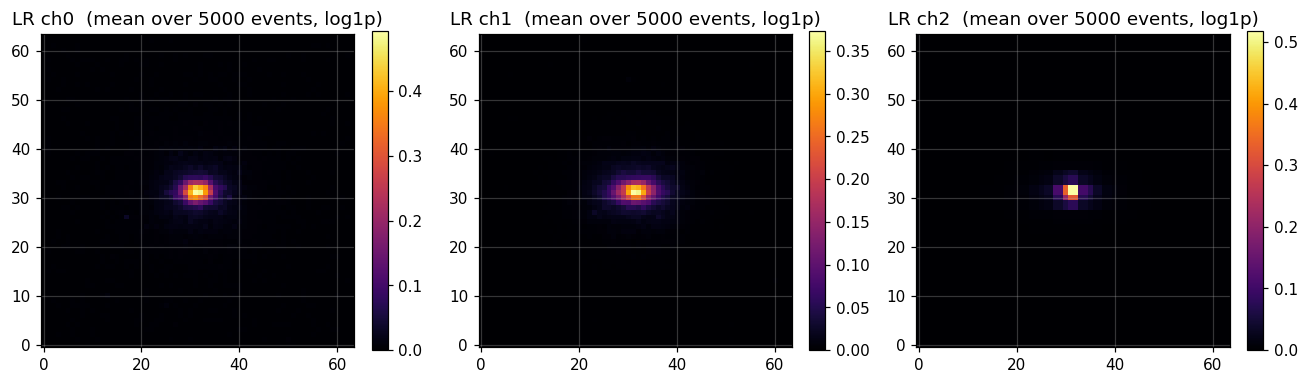

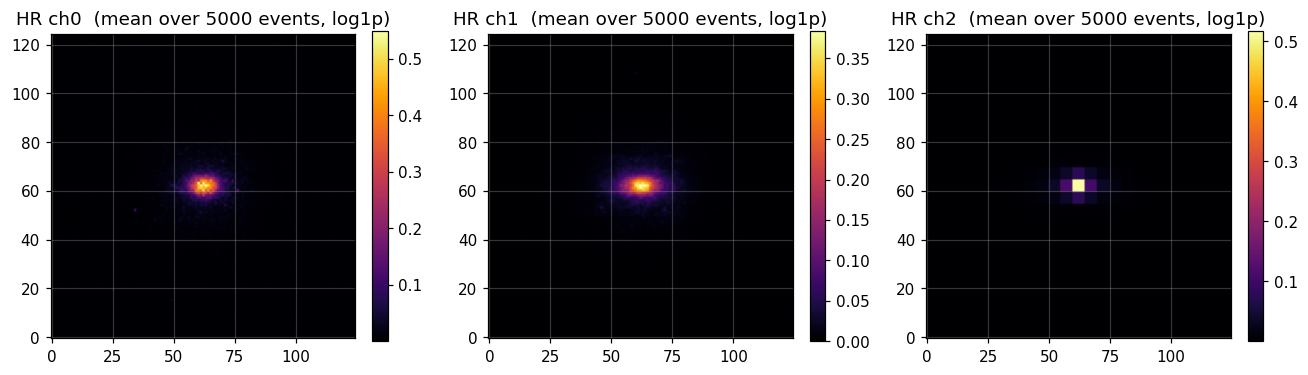

In [31]:
# Mean image per channel, for LR and HR (log scale for visibility)
def show_mean_image(imgs, label, fname):
    mean_img = imgs.mean(axis=0)  # (3, H, W)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for c in range(3):
        m = mean_img[c]
        im = axes[c].imshow(np.log1p(m), cmap="inferno", origin="lower")
        axes[c].set_title(f"{label} ch{c}  (mean over {imgs.shape[0]} events, log1p)")
        fig.colorbar(im, ax=axes[c], fraction=0.046)
    fig.tight_layout(); fig.savefig(FIG_DIR / fname); plt.show()
    return mean_img

lr_mean = show_mean_image(data["lr"], "LR", "05_mean_image_lr.png")
hr_mean = show_mean_image(data["hr"], "HR", "05_mean_image_hr.png")

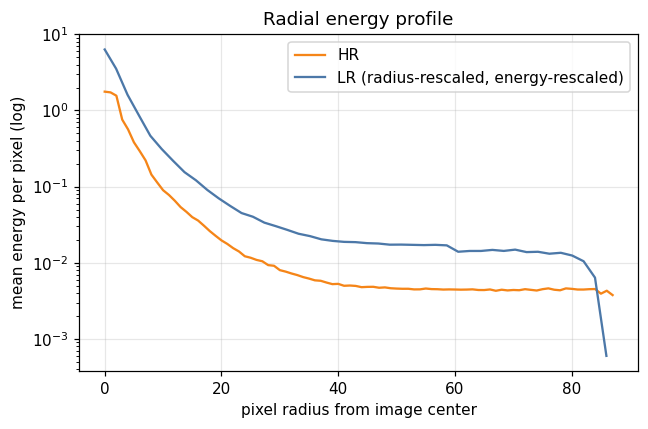

In [32]:
# Radial energy profile (HR, summed over channels) — distance from image center
def radial_profile(mean_img_3ch: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    img = mean_img_3ch.sum(axis=0)  # (H, W)
    h, w = img.shape
    yy, xx = np.indices(img.shape)
    cy, cx = (h - 1) / 2.0, (w - 1) / 2.0
    r = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2).astype(np.int32)
    tbin = np.bincount(r.ravel(), img.ravel())
    nr = np.bincount(r.ravel())
    radial = tbin / np.maximum(nr, 1)
    return np.arange(radial.size), radial

r_hr, prof_hr = radial_profile(hr_mean)
r_lr, prof_lr = radial_profile(lr_mean)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(r_hr, prof_hr, label="HR", color="#F58518")
ax.plot(r_lr * (125 / 64), prof_lr * (125 / 64) ** 2, label="LR (radius-rescaled, energy-rescaled)", color="#4C78A8")
ax.set_yscale("log")
ax.set_xlabel("pixel radius from image center"); ax.set_ylabel("mean energy per pixel (log)")
ax.set_title("Radial energy profile"); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "05_radial_profile.png"); plt.show()

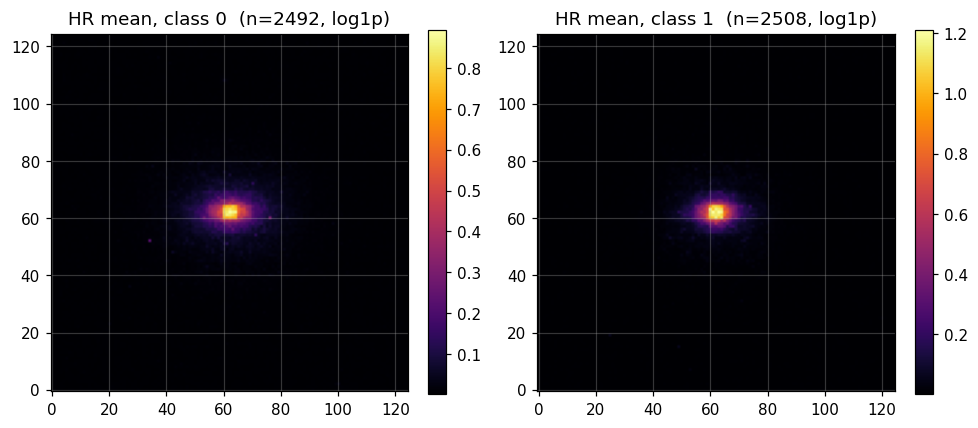

In [33]:
# Per-class mean HR image (channel-summed) — do classes differ spatially?
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, cls in zip(axes, sorted(np.unique(data["y"]))):
    mask = data["y"] == cls
    mi = data["hr"][mask].mean(axis=0).sum(axis=0)
    im = ax.imshow(np.log1p(mi), cmap="inferno", origin="lower")
    ax.set_title(f"HR mean, class {cls}  (n={mask.sum()}, log1p)")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout(); fig.savefig(FIG_DIR / "05_mean_image_per_class.png"); plt.show()

## 6. Pixel intensity distributions
**Question:** Is log1p the right transform? Does it bring the distribution closer to Gaussian?

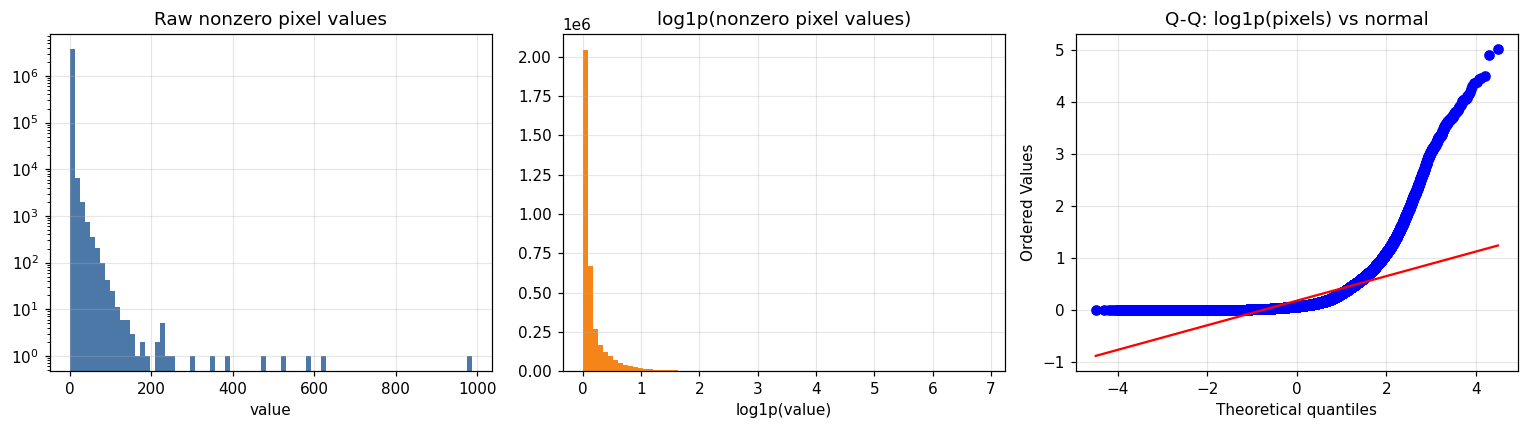

raw nonzero pixels:   mean=0.334, std=1.918, max=986.863, span (orders of magnitude) ≈ 9.83
log1p nonzero pixels: mean=0.184, std=0.323, skew=4.550


In [34]:
# Pool all nonzero HR pixel values (channel-agnostic for a global view)
all_hr = data["hr"].ravel()
nz = all_hr[all_hr > 0]
log_nz = np.log1p(nz)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(nz, bins=80, color="#4C78A8"); axes[0].set_yscale("log")
axes[0].set_title("Raw nonzero pixel values"); axes[0].set_xlabel("value")

axes[1].hist(log_nz, bins=80, color="#F58518")
axes[1].set_title("log1p(nonzero pixel values)"); axes[1].set_xlabel("log1p(value)")

# Q-Q plot vs normal, after log1p
from scipy import stats as sstats
sample = log_nz if log_nz.size < 200_000 else np.random.choice(log_nz, 200_000, replace=False)
sstats.probplot(sample, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q: log1p(pixels) vs normal")
fig.tight_layout(); fig.savefig(FIG_DIR / "06_pixel_transforms.png"); plt.show()

print(f"raw nonzero pixels:   mean={nz.mean():.3f}, std={nz.std():.3f}, max={nz.max():.3f}, span (orders of magnitude) ≈ {np.log10(nz.max() / max(nz.min(), 1e-9)):.2f}")
print(f"log1p nonzero pixels: mean={log_nz.mean():.3f}, std={log_nz.std():.3f}, skew={sstats.skew(log_nz):.3f}")

## 7. LR ↔ HR alignment
**Question:** Is the LR image a downsample of HR, or independently reconstructed? Critical: the GAN uses residual learning on top of bicubic-upsampled LR — this only makes sense if bicubic(LR) ≈ HR structurally.

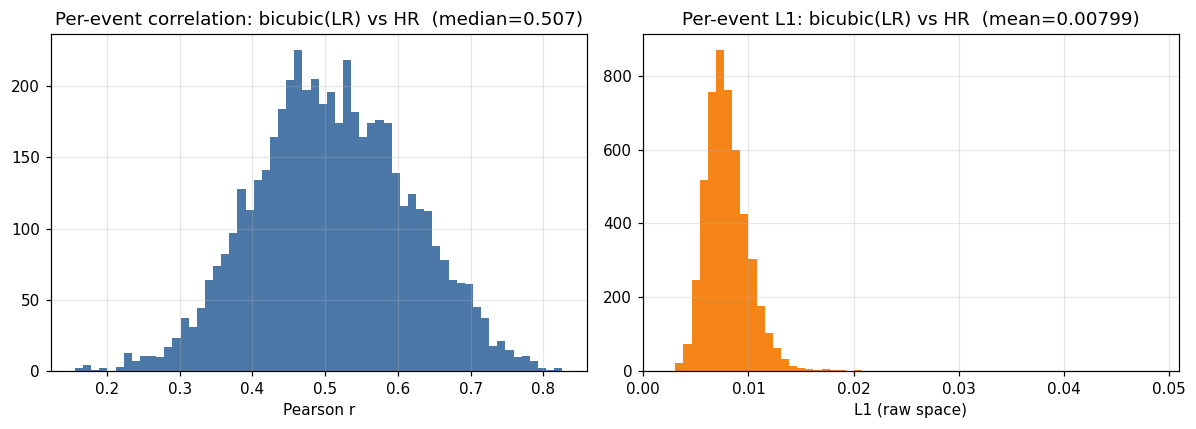

In [35]:
# Bicubic upsample LR to 125x125 and compare to HR
lr_t = torch.from_numpy(data["lr"]).float()
hr_t = torch.from_numpy(data["hr"]).float()
lr_up = F.interpolate(lr_t, size=(125, 125), mode="bicubic", align_corners=False).numpy()

# Per-event Pearson correlation between bicubic(LR) and HR (channel-summed)
lr_up_flat = lr_up.sum(axis=1).reshape(lr_up.shape[0], -1)
hr_flat = data["hr"].sum(axis=1).reshape(data["hr"].shape[0], -1)

def per_event_corr(a, b):
    a = a - a.mean(axis=1, keepdims=True)
    b = b - b.mean(axis=1, keepdims=True)
    num = (a * b).sum(axis=1)
    den = np.sqrt((a * a).sum(axis=1) * (b * b).sum(axis=1)) + 1e-12
    return num / den

corr = per_event_corr(lr_up_flat, hr_flat)
l1 = np.abs(lr_up - data["hr"]).mean(axis=(1, 2, 3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(corr, bins=60, color="#4C78A8")
axes[0].set_title(f"Per-event correlation: bicubic(LR) vs HR  (median={np.median(corr):.3f})")
axes[0].set_xlabel("Pearson r")
axes[1].hist(l1, bins=60, color="#F58518")
axes[1].set_title(f"Per-event L1: bicubic(LR) vs HR  (mean={l1.mean():.5f})")
axes[1].set_xlabel("L1 (raw space)")
fig.tight_layout(); fig.savefig(FIG_DIR / "07_alignment_metrics.png"); plt.show()

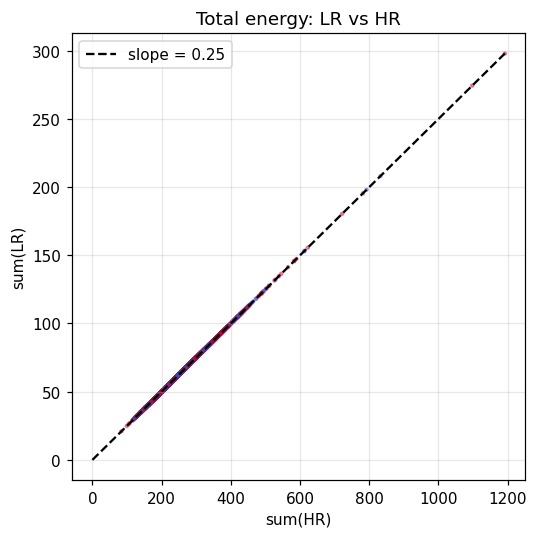

In [36]:
# sum(LR) vs sum(HR) scatter — if LR is a clean downsample, this is linear
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(hr_sum, lr_sum, s=4, alpha=0.4, c=data["y"], cmap="coolwarm")
lims = [0, max(hr_sum.max(), lr_sum.max())]
ax.plot(lims, [0.25 * v for v in lims], "k--", label="slope = 0.25")
ax.set_xlabel("sum(HR)"); ax.set_ylabel("sum(LR)")
ax.set_title("Total energy: LR vs HR"); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / "07_sum_lr_vs_hr.png"); plt.show()

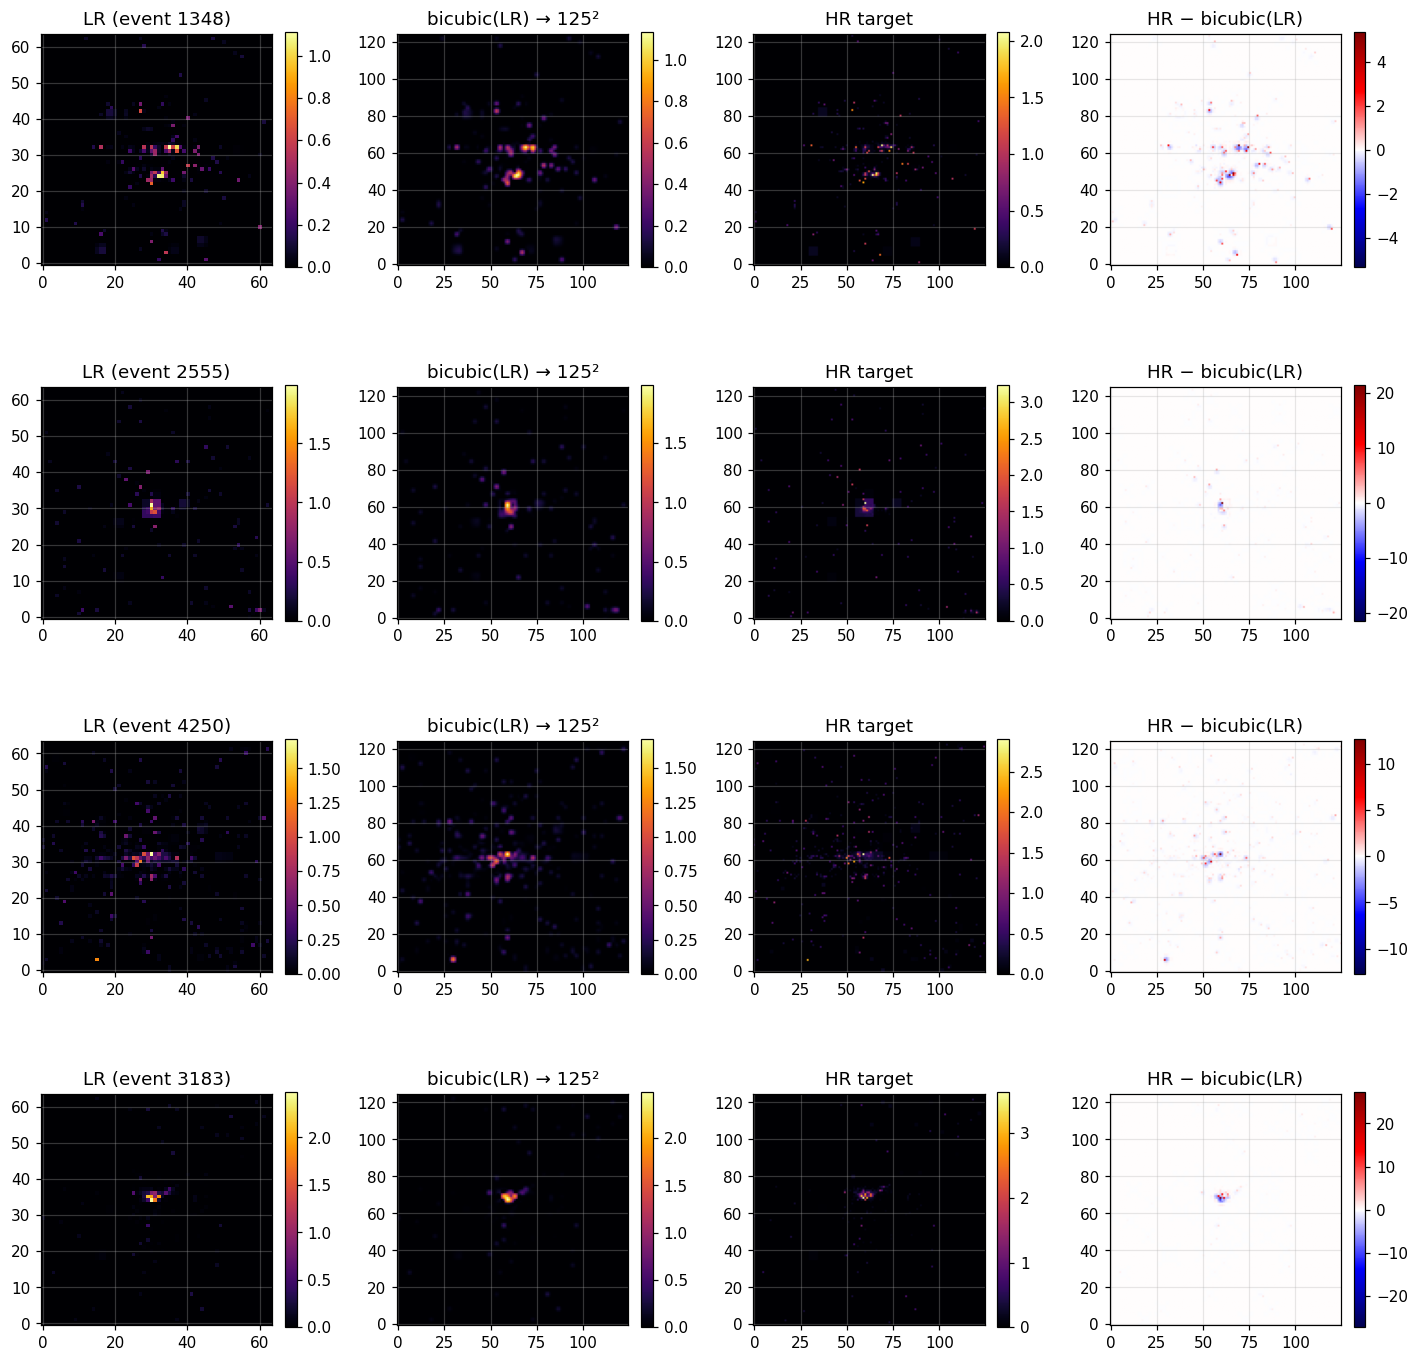

In [37]:
# Qualitative grid: 4 random events — LR | bicubic(LR) | HR | (HR - bicubic(LR))
rng = np.random.default_rng(0)
idx = rng.choice(data["lr"].shape[0], size=4, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(13, 13))
for row, i in enumerate(idx):
    lr_img = data["lr"][i].sum(axis=0)
    up_img = lr_up[i].sum(axis=0)
    hr_img = data["hr"][i].sum(axis=0)
    diff   = hr_img - up_img
    for col, (img, title) in enumerate(zip(
        [lr_img, up_img, hr_img, diff],
        [f"LR (event {i})", "bicubic(LR) → 125²", "HR target", "HR − bicubic(LR)"]
    )):
        cmap = "inferno" if col < 3 else "seismic"
        data_to_show = np.log1p(np.clip(img, 0, None)) if col < 3 else img
        vlim = np.abs(diff).max() if col == 3 else None
        kw = {"vmin": -vlim, "vmax": vlim} if col == 3 else {}
        im = axes[row, col].imshow(data_to_show, cmap=cmap, origin="lower", **kw)
        axes[row, col].set_title(title); fig.colorbar(im, ax=axes[row, col], fraction=0.046)
fig.tight_layout(); fig.savefig(FIG_DIR / "07_qualitative_grid.png"); plt.show()

## 8. Physics correlations
**Question:** Do pt and m0 correlate with image-derived quantities? Strong correlation = FiLM conditioning on (pt, m0) carries signal.

               pt     m0  sum_LR  sum_HR  response  nz_frac_HR  nz_frac_LR
pt          1.000  0.561   0.712   0.712    -0.014       0.314       0.244
m0          0.561  1.000   0.464   0.464    -0.006       0.634       0.634
sum_LR      0.712  0.464   1.000   1.000    -0.011       0.503       0.484
sum_HR      0.712  0.464   1.000   1.000    -0.011       0.503       0.484
response   -0.014 -0.006  -0.011  -0.011     1.000      -0.012      -0.011
nz_frac_HR  0.314  0.634   0.503   0.503    -0.012       1.000       0.950
nz_frac_LR  0.244  0.634   0.484   0.484    -0.011       0.950       1.000


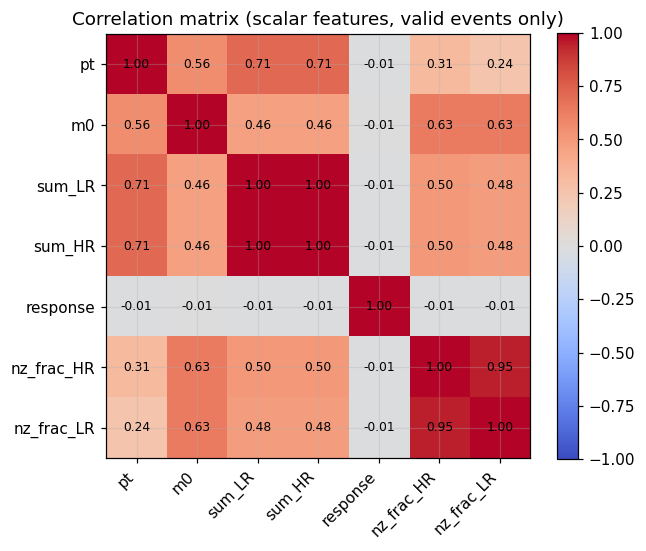

In [38]:
# Build correlation table on the valid (positive-energy) subset so `response` aligns
df = pd.DataFrame({
    "pt": data["pt"][valid],
    "m0": data["m0"][valid],
    "y": data["y"][valid],
    "sum_LR": lr_sum[valid],
    "sum_HR": hr_sum[valid],
    "response": response,
    "nz_frac_HR": (data["hr"][valid] != 0).mean(axis=(1, 2, 3)),
    "nz_frac_LR": (data["lr"][valid] != 0).mean(axis=(1, 2, 3)),
})
corr_mat = df.drop(columns=["y"]).corr()
print(corr_mat.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_mat, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_mat))); ax.set_xticklabels(corr_mat.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_mat))); ax.set_yticklabels(corr_mat.columns)
for i in range(len(corr_mat)):
    for j in range(len(corr_mat)):
        ax.text(j, i, f"{corr_mat.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax)
ax.set_title("Correlation matrix (scalar features, valid events only)")
fig.tight_layout(); fig.savefig(FIG_DIR / "08_correlation_matrix.png"); plt.show()

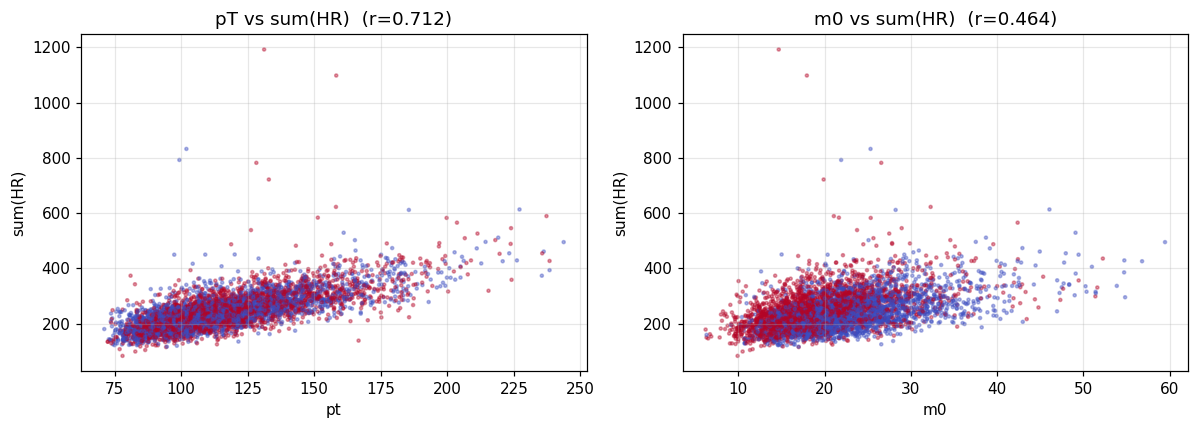

In [39]:
# pt vs sum(HR) and m0 vs sum(HR) — on the valid subset
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, key, title in zip(axes, ["pt", "m0"], ["pT vs sum(HR)", "m0 vs sum(HR)"]):
    ax.scatter(df[key], df["sum_HR"], s=4, alpha=0.4, c=df["y"], cmap="coolwarm")
    r_pearson = df[[key, "sum_HR"]].corr().iloc[0, 1]
    ax.set_xlabel(key); ax.set_ylabel("sum(HR)")
    ax.set_title(f"{title}  (r={r_pearson:.3f})")
fig.tight_layout(); fig.savefig(FIG_DIR / "08_physics_scatter.png"); plt.show()

## 9. Outlier scan
**Question:** Are there pathological events (near-empty, NaN, absurd response)? Decide: keep, filter, or flag.

In [40]:
# Outlier scan — operate on full-length arrays for energy sums, masked `response` for ratio checks
outliers = {
    "n_events_total": int(lr_sum.size),
    "n_events_dropped_for_response": int((~valid).sum()),
    "sum_HR_negative": int((hr_sum < 0).sum()),
    "sum_LR_negative": int((lr_sum < 0).sum()),
    "sum_HR_below_1e-3": int((hr_sum < 1e-3).sum()),
    "sum_LR_below_1e-3": int((lr_sum < 1e-3).sum()),
    "response_outside_[0.1, 0.5]": int(((response < 0.1) | (response > 0.5)).sum()),
    "response_outside_[0.2, 0.3]": int(((response < 0.2) | (response > 0.3)).sum()),
    "response_above_1.0": int((response > 1.0).sum()),
    "hr_has_nan": int(np.isnan(data["hr"]).any(axis=(1, 2, 3)).sum()),
    "hr_has_inf": int(np.isinf(data["hr"]).any(axis=(1, 2, 3)).sum()),
    "hr_has_negative_pixels": int((data["hr"].min(axis=(1, 2, 3)) < 0).sum()),
    "lr_has_negative_pixels": int((data["lr"].min(axis=(1, 2, 3)) < 0).sum()),
}
print(json.dumps(outliers, indent=2))

{
  "n_events_total": 5000,
  "n_events_dropped_for_response": 0,
  "sum_HR_negative": 0,
  "sum_LR_negative": 0,
  "sum_HR_below_1e-3": 0,
  "sum_LR_below_1e-3": 0,
  "response_outside_[0.1, 0.5]": 0,
  "response_outside_[0.2, 0.3]": 0,
  "response_above_1.0": 0,
  "hr_has_nan": 0,
  "hr_has_inf": 0,
  "hr_has_negative_pixels": 4996,
  "lr_has_negative_pixels": 4986
}


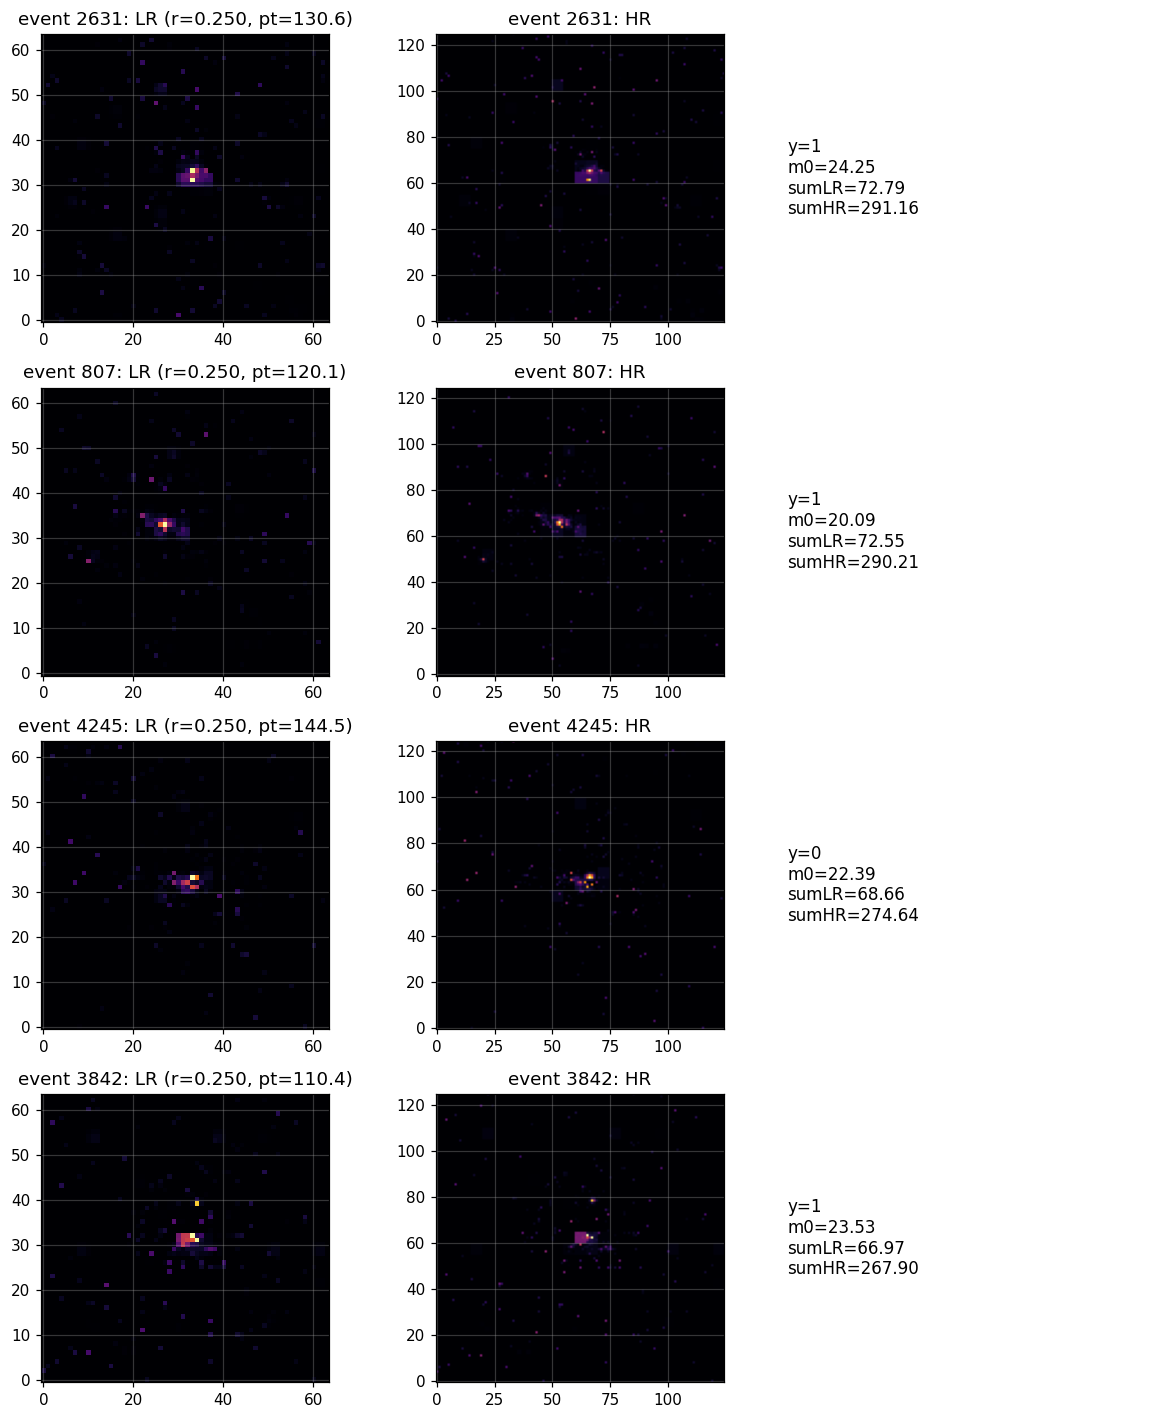

In [41]:
# Show 4 most extreme events by |response - median|
# `response` indexes valid events; map back to original event indices via `valid`
valid_idx = np.flatnonzero(valid)
med = np.median(response)
worst_in_valid = np.argsort(-np.abs(response - med))[:4]
worst_orig = valid_idx[worst_in_valid]

fig, axes = plt.subplots(4, 3, figsize=(11, 13))
for row, (vi, oi) in enumerate(zip(worst_in_valid, worst_orig)):
    lr_img = data["lr"][oi].sum(axis=0)
    hr_img = data["hr"][oi].sum(axis=0)
    axes[row, 0].imshow(np.log1p(np.clip(lr_img, 0, None)), cmap="inferno", origin="lower")
    axes[row, 0].set_title(f"event {oi}: LR (r={response[vi]:.3f}, pt={data['pt'][oi]:.1f})")
    axes[row, 1].imshow(np.log1p(np.clip(hr_img, 0, None)), cmap="inferno", origin="lower")
    axes[row, 1].set_title(f"event {oi}: HR")
    axes[row, 2].axis("off")
    axes[row, 2].text(0, 0.5,
        f"y={data['y'][oi]}\nm0={data['m0'][oi]:.2f}\nsumLR={lr_sum[oi]:.2f}\nsumHR={hr_sum[oi]:.2f}",
        fontsize=11, va="center")
fig.tight_layout(); fig.savefig(FIG_DIR / "09_outliers.png"); plt.show()

## 10. Modeling implications — summary

Each bullet is a modeling decision in the GSoC proposal, paired with the section that supports or challenges it. Fill in concrete numbers from the cells above after running.

- **log1p transform** — justified by §6 if raw pixels span many orders of magnitude and log1p reduces skew toward Gaussian. *Observed span:* `___` orders of magnitude; *log1p skew:* `___`.
- **Per-channel z-score normalization** — justified by §3 if channels differ significantly in mean/std. *Observed energy fractions:* `(ch0, ch1, ch2) = ___`.
- **Energy-conservation loss** — justified by §4 if the per-event response distribution is wide and a pixel-only loss cannot constrain total energy. *Observed response std:* `___`.
- **η-φ positional bias in SwinIR** — justified by §5 if energy is radially concentrated. *Observed radial profile:* energy drops by `___×` from center to edge.
- **FiLM conditioning on (pt, m0, y)** — justified by §8 if these correlate meaningfully with image quantities. *Observed correlations:* `pt↔sum(HR) = ___`, `m0↔sum(HR) = ___`.
- **Residual learning on top of bicubic(LR)** — justified by §7 if bicubic(LR) correlates strongly with HR. *Observed median correlation:* `___`.
- **Class-wise response gap baseline to beat** — §4 measures this on data, not on a model. *Observed |mean(r_class0) − mean(r_class1)|:* `___`. Proposal baseline GAN achieves 0.0091; any new architecture must match or beat this.
- **Outliers** — §9 decides. *Decision:* keep / filter / flag (mark when reviewed).

## Persist summary

In [42]:
summary = {
    "mode": MODE,
    "n_events_analyzed": int(data["y"].shape[0]),
    "n_events_valid_for_response": int(valid.sum()),
    "files": data["files"],
    "response": {
        "mean": float(response.mean()),
        "std": float(response.std()),
        "median": float(np.median(response)),
        "per_class_mean": {int(c): float(response[y_valid == c].mean()) for c in np.unique(y_valid)},
        "per_class_median": {int(c): float(np.median(response[y_valid == c])) for c in np.unique(y_valid)},
        "per_class_gap_mean": float(abs(response[y_valid == 0].mean() - response[y_valid == 1].mean())),
        "per_class_gap_median": float(abs(np.median(response[y_valid == 0]) - np.median(response[y_valid == 1]))),
    },
    "channel_stats": chan_stats.to_dict(orient="records"),
    "outliers": outliers,
    "correlations": corr_mat.to_dict(),
}
(OUT_DIR / "eda_summary.json").write_text(json.dumps(summary, indent=2, default=str))
print(f"Wrote {OUT_DIR / 'eda_summary.json'}")
print(f"Figures: {FIG_DIR}")

Wrote /Users/rajveerrathod/Work/Google_Summer_of_code/task/reports/eda/eda_summary.json
Figures: /Users/rajveerrathod/Work/Google_Summer_of_code/task/reports/eda/figures
